# FoundationStereo PyTorch component profile

Reuses the same capture, rectification, and stereo images as `DINOVL_test.ipynb`. The rectified images are resized directly to **576 × 960** (height × width), then passed once to `FoundationStereo.forward(..., test_mode=True)`.

There is no TensorRT engine, no Hiera path, no warmup, and no second refinement pass. The notebook reports only the total direct-forward inference time and the GPU memory consumed by that forward. This notebook requires a PyTorch build compatible with the active GPU.

In [13]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from time import perf_counter
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from omegaconf import OmegaConf

from fs_high_resolution_utils import (
    configure_capture,
    load_rectify_and_select_mask,
    show_rectified_selection,
)

REPO_ROOT = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents)
     if (candidate / 'FoundationStereo').is_dir() and (candidate / 'weight').is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError('Open this notebook from the FS_Engine repository or python/ directory.')
REPO_ROOT = REPO_ROOT.resolve()
FS_ROOT = REPO_ROOT / 'FoundationStereo'
WEIGHTS_DIR = REPO_ROOT / 'weight' / '23-51-11'
if str(FS_ROOT) not in sys.path:
    sys.path.insert(0, str(FS_ROOT))
if not torch.cuda.is_available():
    raise RuntimeError('PyTorch CUDA is required for this profile.')

import core.foundation_stereo as foundation_stereo_module
from core.foundation_stereo import FoundationStereo

DEVICE = torch.device('cuda:0')
print('Repository:', REPO_ROOT)
print('GPU:', torch.cuda.get_device_name(DEVICE), 'sm_' + ''.join(map(str, torch.cuda.get_device_capability(DEVICE))))
print('PyTorch:', torch.__version__, '| CUDA:', torch.version.cuda)
print('Checkpoint:', WEIGHTS_DIR / 'model_best_bp2.pth')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Repository: /home/liu4000/Desktop/FS_Engine
GPU: NVIDIA RTX PRO 4000 Blackwell sm_120
PyTorch: 2.13.0+cu132 | CUDA: 13.2
Checkpoint: /home/liu4000/Desktop/FS_Engine/weight/23-51-11/model_best_bp2.pth


In [14]:
cfg = OmegaConf.load(WEIGHTS_DIR / 'cfg.yaml')
cfg.vit_size = 'vitl'  # Matches the local 23-51-11 checkpoint.
model = FoundationStereo(cfg)
checkpoint = torch.load(WEIGHTS_DIR / 'model_best_bp2.pth', weights_only=False, map_location='cpu')
model.load_state_dict(checkpoint['model'])
model = model.to(DEVICE).eval()
for parameter in model.parameters():
    parameter.requires_grad_(False)
del checkpoint
print('Loaded FoundationStereo with vit_size =', cfg.vit_size)

Using cache found in /home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main
using MLP layer as FFN


Loaded FoundationStereo with vit_size = vitl


Capture: /home/liu4000/Desktop/FS_Engine/data/Volunteer2_lower/0
Rectified: 2448×2048, fx=1723.58, baseline=0.055079 m


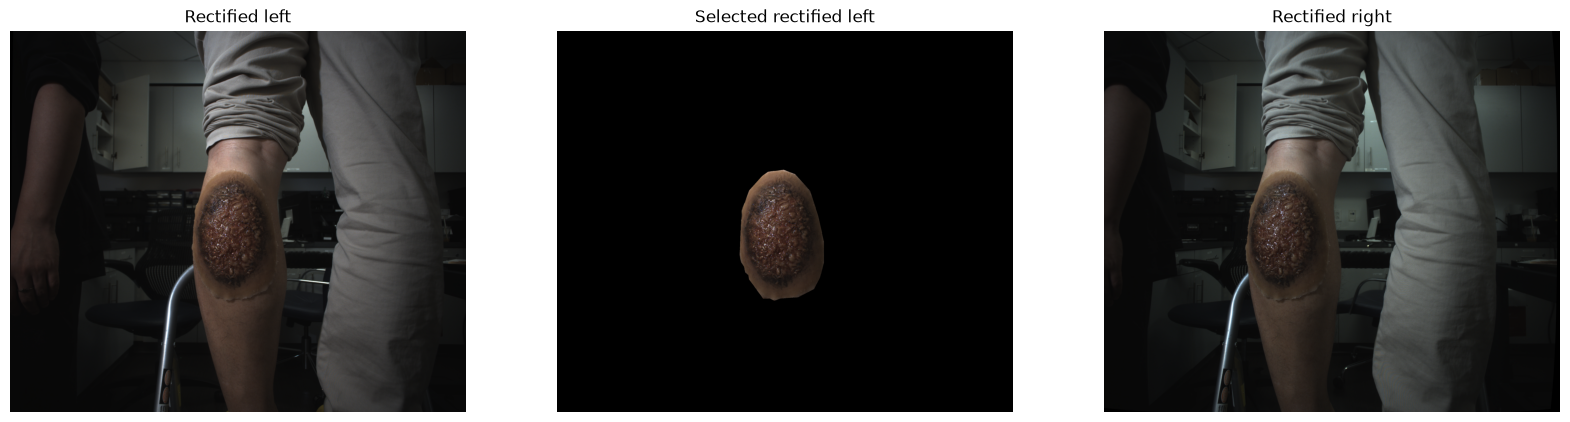

In [15]:
# Same capture selection and stereo rectification path as DINOVL_test.ipynb.
CAPTURE_DIR = configure_capture(globals(), REPO_ROOT)
rectified_left, rectified_right, rectified_K, baseline_m, rectified_left_mask = load_rectify_and_select_mask(
    globals(), LEFT_PATH, RIGHT_PATH, LEFT_MASK_PATH, CALIBRATION_PATH, EXPECTED_WIDTH, EXPECTED_HEIGHT
)
print(f'Capture: {CAPTURE_DIR}')
print(f'Rectified: {rectified_left.shape[1]}×{rectified_left.shape[0]}, fx={rectified_K[0, 0]:.2f}, baseline={baseline_m:.6f} m')
show_rectified_selection(rectified_left, rectified_left_mask, rectified_right)

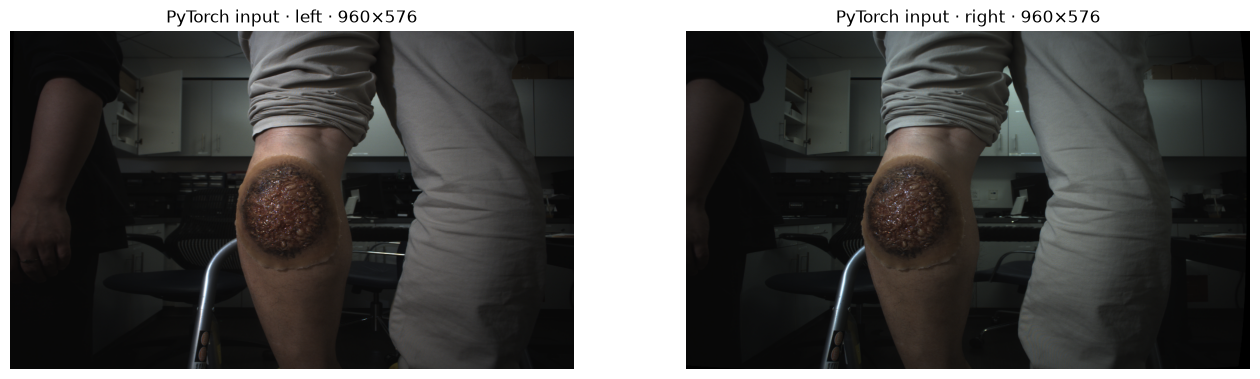

In [16]:
MODEL_HEIGHT, MODEL_WIDTH = 576, 960
VALID_ITERS = int(cfg.valid_iters)

def to_model_tensor(image_rgb: np.ndarray) -> torch.Tensor:
    resized = cv2.resize(image_rgb, (MODEL_WIDTH, MODEL_HEIGHT), interpolation=cv2.INTER_LINEAR)
    nchw = np.ascontiguousarray(resized.transpose(2, 0, 1)[None].astype(np.float32))
    return torch.from_numpy(nchw).to(DEVICE, non_blocking=True)

left = to_model_tensor(rectified_left)
right = to_model_tensor(rectified_right)
assert left.shape == right.shape == (1, 3, MODEL_HEIGHT, MODEL_WIDTH)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for axis, image, title in zip(axes, (left[0].permute(1, 2, 0).cpu().numpy(), right[0].permute(1, 2, 0).cpu().numpy()),
                              ('PyTorch input · left · 960×576', 'PyTorch input · right · 960×576')):
    axis.imshow(image.astype(np.uint8))
    axis.set_title(title)
    axis.axis('off')
plt.show()

In [17]:
WARMUP_RUNS = 1
BENCHMARK_RUNS = 10

# Full forward warm-up is deliberately excluded from both timing and memory measurements.
with torch.inference_mode(), torch.autocast(device_type='cuda', dtype=torch.float16):
    for _ in range(WARMUP_RUNS):
        model.forward(left, right, iters=VALID_ITERS, test_mode=True, low_memory=False)
torch.cuda.synchronize(DEVICE)

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats(DEVICE)
forward_times_ms = []
feature_starts, feature_event_pairs = [], []
cost_volume_starts, cost_volume_event_pairs = [], []
gru_starts, gru_event_pairs = [], []
upsample_event_pairs = []

def _feature_started(module, inputs):
    start = torch.cuda.Event(enable_timing=True)
    start.record()
    feature_starts.append(start)

def _feature_finished(module, inputs, output):
    end = torch.cuda.Event(enable_timing=True)
    end.record()
    feature_event_pairs.append((feature_starts.pop(), end))

def _cost_volume_started(*args, **kwargs):
    start = torch.cuda.Event(enable_timing=True)
    start.record()
    cost_volume_starts.append(start)
    return original_build_gwc_volume(*args, **kwargs)

def _cost_volume_finished(module, inputs):
    end = torch.cuda.Event(enable_timing=True)
    end.record()
    cost_volume_event_pairs.append((cost_volume_starts.pop(), end))

def _gru_started(module, inputs):
    start = torch.cuda.Event(enable_timing=True)
    start.record()
    gru_starts.append(start)

def _gru_finished(module, inputs, output):
    end = torch.cuda.Event(enable_timing=True)
    end.record()
    gru_event_pairs.append((gru_starts.pop(), end))

def _timed_upsample_disp(*args, **kwargs):
    start = torch.cuda.Event(enable_timing=True)
    start.record()
    output = original_upsample_disp(*args, **kwargs)
    end = torch.cuda.Event(enable_timing=True)
    end.record()
    upsample_event_pairs.append((start, end))
    return output

# These hooks time model.feature within each full forward; they never run it separately.
pre_handle = model.feature.register_forward_pre_hook(_feature_started)
post_handle = model.feature.register_forward_hook(_feature_finished)
# Cost-volume scope: build_gwc_volume through initial disparity, immediately before cnet.
original_build_gwc_volume = foundation_stereo_module.build_gwc_volume
foundation_stereo_module.build_gwc_volume = _cost_volume_started
cost_volume_end_handle = model.cnet.register_forward_pre_hook(_cost_volume_finished)
gru_pre_handle = model.update_block.register_forward_pre_hook(_gru_started)
gru_post_handle = model.update_block.register_forward_hook(_gru_finished)
original_upsample_disp = model.upsample_disp
model.upsample_disp = _timed_upsample_disp
try:
    with torch.inference_mode(), torch.autocast(device_type='cuda', dtype=torch.float16):
        for _ in range(BENCHMARK_RUNS):
            torch.cuda.synchronize(DEVICE)
            wall_started = perf_counter()
            disparity = model.forward(left, right, iters=VALID_ITERS, test_mode=True, low_memory=False)
            torch.cuda.synchronize(DEVICE)
            forward_times_ms.append((perf_counter() - wall_started) * 1_000)
finally:
    pre_handle.remove()
    post_handle.remove()
    cost_volume_end_handle.remove()
    gru_pre_handle.remove()
    gru_post_handle.remove()
    foundation_stereo_module.build_gwc_volume = original_build_gwc_volume
    model.upsample_disp = original_upsample_disp

feature_dino_times_ms = [start.elapsed_time(end) for start, end in feature_event_pairs]
cost_volume_times_ms = [start.elapsed_time(end) for start, end in cost_volume_event_pairs]
gru_times_ms = [start.elapsed_time(end) for start, end in gru_event_pairs]
upsample_times_ms = [start.elapsed_time(end) for start, end in upsample_event_pairs]
if len(gru_times_ms) != BENCHMARK_RUNS * VALID_ITERS or len(upsample_times_ms) != BENCHMARK_RUNS:
    raise RuntimeError('Unexpected GRU or upsample hook count; benchmark results are invalid.')
gru_total_per_forward_ms = np.asarray(gru_times_ms).reshape(BENCHMARK_RUNS, VALID_ITERS).sum(axis=1)
timing_summary = {
    'warmup_runs': WARMUP_RUNS,
    'benchmark_runs': BENCHMARK_RUNS,
    'forward_mean_ms': float(np.mean(forward_times_ms)),
    'forward_min_ms': float(np.min(forward_times_ms)),
    'forward_max_ms': float(np.max(forward_times_ms)),
}
# One comparable memory number: model weights plus the forward's peak live CUDA tensors.
peak_cuda_memory_mib = torch.cuda.max_memory_allocated(DEVICE) / 2**20
print(f'Feature/DINO within full forward (10 runs): mean {np.mean(feature_dino_times_ms):.2f} ms')
print(f'Cost volume / 3D aggregation within full forward (10 runs): mean {np.mean(cost_volume_times_ms):.2f} ms')
print(f'GRU update within full forward (10 runs): mean per iteration {np.mean(gru_times_ms):.2f} ms')
print(f'GRU update within full forward (10 runs): mean total per forward {np.mean(gru_total_per_forward_ms):.2f} ms')
print(f'Disparity upsample within full forward (10 runs): mean {np.mean(upsample_times_ms):.2f} ms')
print('Direct PyTorch forward (10 runs; 1 warm-up excluded): ' +
      f"mean {timing_summary['forward_mean_ms']:.2f} ms | "
      f"min {timing_summary['forward_min_ms']:.2f} ms | max {timing_summary['forward_max_ms']:.2f} ms")
print(f'Peak allocated CUDA memory: {peak_cuda_memory_mib:.2f} MiB')

Feature/DINO within full forward (10 runs): mean 149.74 ms
Cost volume / 3D aggregation within full forward (10 runs): mean 100.24 ms
GRU update within full forward (10 runs): mean per iteration 11.22 ms
GRU update within full forward (10 runs): mean total per forward 358.97 ms
Disparity upsample within full forward (10 runs): mean 1.14 ms
Direct PyTorch forward (10 runs; 1 warm-up excluded): mean 694.82 ms | min 689.27 ms | max 698.15 ms
Peak allocated CUDA memory: 3167.03 MiB


In [ ]:
disparity_576x960 = np.ascontiguousarray(disparity.float().squeeze().cpu().numpy())
assert disparity_576x960.shape == (MODEL_HEIGHT, MODEL_WIDTH)
output_dir = REPO_ROOT / 'result' / CAPTURE_DIR.relative_to(REPO_ROOT / 'data')
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'pytorch_disparity_576x960.npy'
np.save(output_path, disparity_576x960)

finite = disparity_576x960[np.isfinite(disparity_576x960)]
if finite.size == 0:
    raise RuntimeError('PyTorch forward returned no finite disparity values')
limit = float(np.percentile(finite, 99))
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(left[0].permute(1, 2, 0).cpu().numpy().astype(np.uint8))
axes[0].set_title('Rectified left resized to 960×576')
axes[0].axis('off')
image = axes[1].imshow(disparity_576x960, cmap='turbo', vmin=0, vmax=limit)
axes[1].set_title('PyTorch direct-forward disparity · 960×576')
axes[1].axis('off')
fig.colorbar(image, ax=axes[1], shrink=0.8, label='disparity (resized-image pixels)')
plt.show()
print('Saved:', output_path)